[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/duoan/TorchCode/blob/master/templates/03_linear.ipynb)

# 🟡 Medium: Simple Linear Layer

Implement a fully-connected linear layer: **y = xW^T + b**

### Signature
```python
class SimpleLinear:
    def __init__(self, in_features: int, out_features: int): ...
    def forward(self, x: torch.Tensor) -> torch.Tensor: ...
```

### Requirements
- `self.weight`: shape `(out_features, in_features)`, init with `randn * (1/√in_features)`
- `self.bias`: shape `(out_features,)`, init as zeros
- Both must have `requires_grad=True`
- `forward(x)` computes `x @ W^T + b`
- Do **NOT** use `torch.nn.Linear`

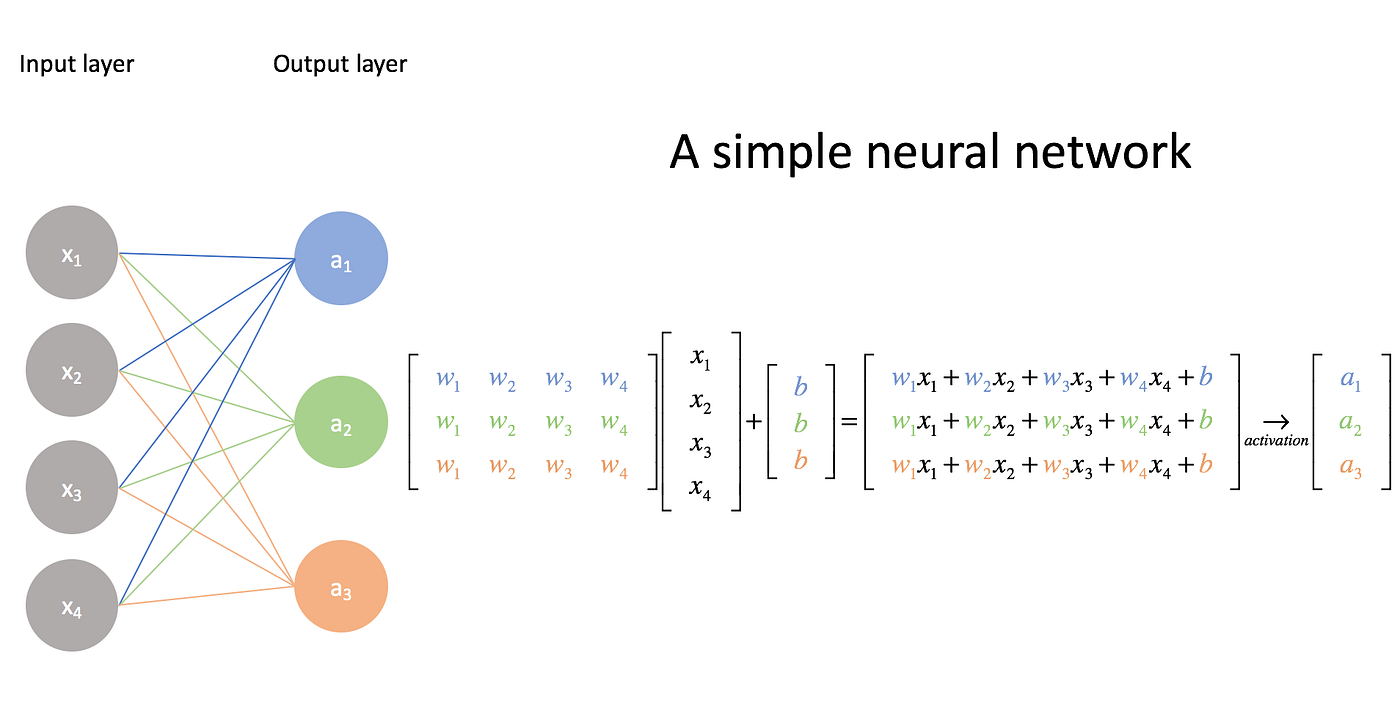

In [2]:
# Install torch-judge in Colab (no-op in JupyterLab/Docker)
try:
    import google.colab
    get_ipython().run_line_magic('pip', 'install -q torch-judge')
except ImportError:
    pass


In [3]:
import torch
import math

In [4]:
# ✏️ YOUR IMPLEMENTATION HERE

class SimpleLinear:
    def __init__(self, in_features: int, out_features: int):
        # pass  # Initialize weight and bias
        self.weight = torch.randn(out_features, in_features) / math.sqrt(in_features)
        self.bias = torch.zeros(out_features)
        self.weight.requires_grad_()
        self.bias.requires_grad_()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # pass  # Compute y = x @ W^T + b
        return x @ self.weight.T + self.bias
    

In [5]:
# 🧪 Debug
layer = SimpleLinear(8, 4)
print("W shape:", layer.weight.shape)  # should be (4, 8)
print("b shape:", layer.bias.shape)    # should be (4,)

x = torch.randn(2, 8)
y = layer.forward(x)
print("Output shape:", y.shape)        # should be (2, 4)

W shape: torch.Size([4, 8])
b shape: torch.Size([4])
Output shape: torch.Size([2, 4])


In [6]:
y

tensor([[-1.1259, -0.2728,  0.1129,  0.1137],
        [-0.2056, -0.5247, -0.9103, -0.3305]], grad_fn=<AddBackward0>)

In [39]:
print((y * 10).sum())
(y * 10).sum().backward()
print(y.grad)
print(y.is_leaf)
print(layer.weight.grad)
print(layer.weight.is_leaf)
print(layer.bias.grad)
print(layer.bias.is_leaf)

tensor(10.5548, grad_fn=<SumBackward0>)
None
False
tensor([[  0.9557, -17.2823,  -5.7054,  12.2297, -25.6831,  15.6065,  12.0843,
          -0.5226],
        [  0.9557, -17.2823,  -5.7054,  12.2297, -25.6831,  15.6065,  12.0843,
          -0.5226],
        [  0.9557, -17.2823,  -5.7054,  12.2297, -25.6831,  15.6065,  12.0843,
          -0.5226],
        [  0.9557, -17.2823,  -5.7054,  12.2297, -25.6831,  15.6065,  12.0843,
          -0.5226]])
True
tensor([20., 20., 20., 20.])
True


/tmp/ipykernel_1426462/1406115230.py:3: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:494.)
  print(y.grad)


In [7]:
# ✅ SUBMIT
from torch_judge import check
check("linear")


🧪 Testing: Simple Linear Layer (Medium)
──────────────────────────────────────────────────
  ✅ [1/3] Weight & bias shape (0.5ms)
  ✅ [2/3] Forward pass (0.4ms)
  ✅ [3/3] Gradient flow (35.5ms)
──────────────────────────────────────────────────
  🎉 All 3 tests passed! (36.4ms total)
  Progress saved. Run status() to see your dashboard.

